<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Шаг 1. Загрузка и подготовка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>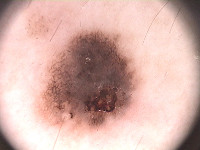</td><td>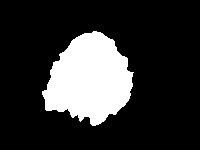</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [1]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=0f742587-b54d-4543-b041-e7dea2a52eff
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 95.4MB/s]


In [2]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [3]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [4]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [5]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

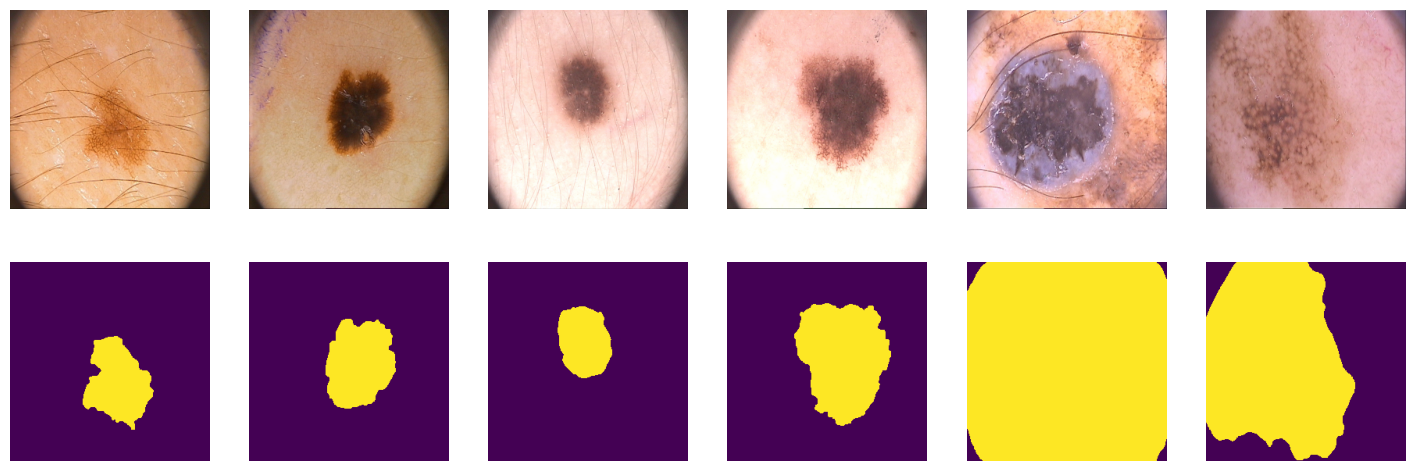

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [7]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [8]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [9]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=False)

In [10]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


# Шаг 2. Метрика качества модели

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [11]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.6 MB/s eta 0:00:00


In [12]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Задания: Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## Шаг 3. Loss функция - BCE [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

## Вывод формулы:

Исходная формула (1):

$$\mathcal{L}_{BCE}(y, \hat{y}) = -\sum_i \left[y_i\log\sigma(\hat{y}_i) + (1-y_i)\log(1-\sigma(\hat{y}_i))\right]$$

где $\sigma(x) = \frac{1}{1+e^{-x}}$.

**Шаг 1.** Раскроем логарифмы:

$$\log\sigma(\hat{y}_i) = -\log(1 + e^{-\hat{y}_i})$$

$$1 - \sigma(\hat{y}_i) = \frac{e^{-\hat{y}_i}}{1+e^{-\hat{y}_i}} \implies \log(1-\sigma(\hat{y}_i)) = -\log(1+e^{\hat{y}_i})$$

**Шаг 2.** Подставим:

$$\mathcal{L} = \sum_i\bigl[y_i\log(1+e^{-\hat{y}_i}) + (1-y_i)\log(1+e^{\hat{y}_i})\bigr]$$

**Шаг 3.**

$$\log(1+e^{\hat{y}}) = \log(e^{\hat{y}}) + \log(1+e^{-\hat{y}}) = \hat{y} + \log(1+e^{-\hat{y}})$$

$$ \Rightarrow \mathcal{L} = \sum_i\bigl[\hat{y}_i - y_i\hat{y}_i + \log(1 + e^{-\hat{y}_i})\bigr]$$

что и требовалоись доказать.


### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [13]:
import torch.nn.functional as F
import torch.nn as nn

In [14]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [15]:
def bce_loss(y_pred, y_real):
    y_real = y_real.float()
    loss = y_pred - y_real * y_pred + torch.log(1 + torch.exp(-y_pred))
    return loss.sum()

def bce_true(y_pred, y_real):
    y_real = y_real.float()
    eps = 1e-12
    p = torch.sigmoid(y_pred)
    loss = -(y_real * torch.log(p + eps) + (1 - y_real) * torch.log(1 - p + eps))
    return loss.sum()

Проверим корректность работы на простом примере

In [16]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss = 4.810200214385986
BCE loss честно посчитанный = 4.8102006912231445
BCE loss from torch bce_torch = 4.8102006912231445
BCE loss from torch with logits bce_torch = 4.810199737548828


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [17]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [18]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss = 15.382389068603516
BCE loss честно посчитанный = 15.382389068603516
BCE loss from torch bce_torch = 15.382389068603516
BCE loss from torch with logits bce_torch = 15.382389068603516


In [19]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [20]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 4.02MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 6.04MB/s]
Download completed


In [21]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

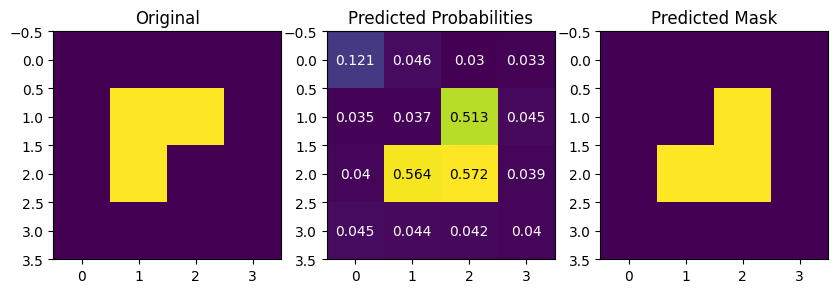

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [23]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## Шаг 4. Модель SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

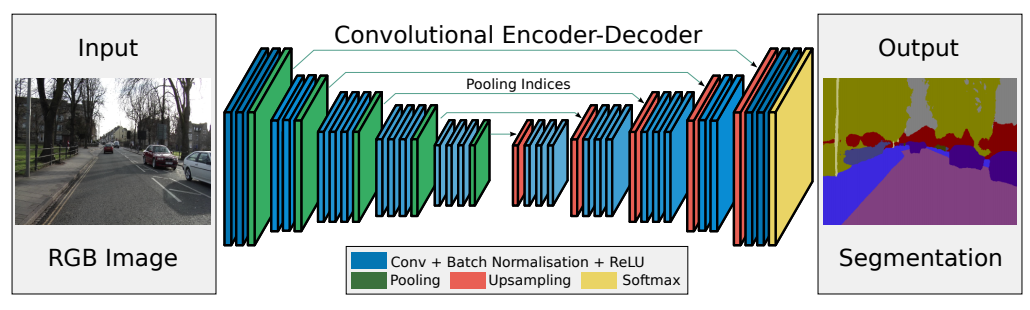

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки. Для этого скачаем и изучим feature extractor VGG-16, который лежит в основе SegNet.

In [25]:
model_vgg16 = models.vgg16(weights = models.VGG16_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 146MB/s]


In [26]:
model_vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Feature extractor VGG-16 состоит из 5 блоков:
- два блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d
- три блока со структурой:
Conv2d -> ReLU -> Conv2d -> ReLU -> Conv2d -> ReLU -> MaxPool2d

В первом блоке - на входе три канала (по числу каналов в изображениях), которые конволюционный слой преобразует в 64 канала.

Во втором, третьем и четвертом блоках первый конволюционный слой удваивает количество каналов, а последующие конволюционные слои не меняют количество каналов.

В последнем блоке число каналов от слоя к слою не меняется.

Теперь напишем код одного блока энкодера нашей модели SegNet.  

In [27]:
# Параметрами блока будут:
# - количество каналов на входе
# - количество каналов на выходе
# - глубина блока (2 или 3, по количеству конволюционных слоев)
# - kernel_size и padding
#
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth, kernel_size = 3, padding = 1):
        super(EncoderBlock, self).__init__() # инициируем экземляр класса, наследующего от nn.Module
        self.layers = nn.ModuleList() # в self.layers будем добавлять слои блока
        # дальше реализуем то, что на картинке выше обозначено Conv + Batch Normalization + ReLU
        self.layers.append(nn.Conv2d(in_channels = in_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
        self.layers.append(nn.BatchNorm2d(out_channels))
        self.layers.append(nn.ReLU(inplace=True))

        # цикл for помогает использовать один код для блоков как с глубиной 2, так и с глубиной 3
        for i in range(depth-1):
            self.layers.append(nn.Conv2d(in_channels = out_channels, out_channels = out_channels, kernel_size = kernel_size, padding = padding))
            self.layers.append(nn.BatchNorm2d(out_channels))
            self.layers.append(nn.ReLU(inplace=True))

        self.maxpooling = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #добавляем MaxPool с индексами для последующего Unpooling

    # Обратите внимание: на вход метод forward() получает карту признаков (х),
    # а возвращает карту признаков и индексы для последующего Unpooling
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x, indices = self.maxpooling(x)
        return x, indices


По аналогии напишите код одного блока декодера.

К карте признаков на входе каждого блока примеяется nn.MaxUnpool2d с индексами из симметричного блока энкодера. Затем повторяется связка Conv + Batch Normalization + ReLU. Количество каналов меняется зеркально блокам энкодера:
- в первом блоке декодера количество каналов не меняется
- во 2-4 блоках декодера количество каналов уменьшается в 2 раза после прохождения последнего конволюционного слоя
- на выходе из последнего блока декодера 1 канал

Обратите внимание, что после последней конволюции последнего блока декодера не применяется батч-нормализация и функция активации.

In [28]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, depth=2, last_block=False):
        super().__init__()
        self.unpool = nn.MaxUnpool2d(kernel_size=2, stride=2)
        layers = []
        for i in range(depth):
            out_ch = out_channels if i == depth - 1 else in_channels
            if last_block and i == depth - 1:
                layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            else:
                layers += [
                    nn.Conv2d(in_channels, out_ch, kernel_size=3, padding=1),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                ]
        self.conv = nn.Sequential(*layers)

    def forward(self, x, indices):
        x = self.unpool(x, indices)
        x = self.conv(x)
        return x

Соединим блоки энкодера и декодера в модель SegNet:

In [29]:
class SegNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_features=64):
        super().__init__()

        # Encoder
        self.encoder0 = EncoderBlock(in_channels, num_features, depth=2)
        self.encoder1 = EncoderBlock(num_features, num_features * 2,  depth=2)
        self.encoder2 = EncoderBlock(num_features * 2, num_features * 4, depth=3)
        self.encoder3 = EncoderBlock(num_features * 4, num_features * 8, depth=3)

        # Encoder bottleneck
        self.encoder4 = EncoderBlock(num_features * 8, num_features * 8,  depth=3)

        # Decoder bottleneck
        self.decoder4 = DecoderBlock(num_features * 8, num_features * 8, depth=3)

        # Decoder
        self.decoder3 = DecoderBlock(num_features * 8, num_features * 4, depth=3)
        self.decoder2 = DecoderBlock(num_features * 4, num_features * 2, depth=3)
        self.decoder1 = DecoderBlock(num_features * 2, num_features, depth=2)
        self.decoder0 = DecoderBlock(num_features, out_channels, depth=2, last_block=True)

    def forward(self, x):
        x, idx0 = self.encoder0(x)
        x, idx1 = self.encoder1(x)
        x, idx2 = self.encoder2(x)
        x, idx3 = self.encoder3(x)
        x, idx4 = self.encoder4(x)

        x = self.decoder4(x, idx4)
        x = self.decoder3(x, idx3)
        x = self.decoder2(x, idx2)
        x = self.decoder1(x, idx1)

        output = self.decoder0(x, idx0)
        return output

## Шаг 5. Тренировка модели [1 балл]

Напишите функции для обучения модели.

In [30]:
from tqdm.notebook import tqdm

In [31]:
def train_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [32]:
def validate_epoch(model, loader, loss_fn, iou_fn, device):
    model.eval()
    total_loss, total_iou = 0.0, 0.0

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            total_loss += loss_fn(preds, masks).item()
            total_iou  += iou_fn(torch.sigmoid(preds), masks.int()).item()

    return total_loss / len(loader), total_iou / len(loader)

In [33]:
def train(model, train_loader, valid_loader, loss_fn, iou_fn,
          device, n_epochs=30, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_iou, best_state = -1.0, None
    history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

    for epoch in tqdm(range(n_epochs), desc='Epochs'):
        tr_loss           = train_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_iou = validate_epoch(model, valid_loader, loss_fn, iou_fn, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)

        if val_iou > best_iou:
            best_iou   = val_iou
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f' Epoch {epoch+1:3d}/{n_epochs}\n Train Loss: {tr_loss:.4f}\n Val Loss: {val_loss:.4f}\n Val IoU: {val_iou:.4f}\n')

    if best_state:
        model.load_state_dict(best_state)

    return history


Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [ ]:
segnet_model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)

loss_fn_bce = nn.BCEWithLogitsLoss(reduction='mean')

history_segnet_bce = train(
    model = segnet_model,
    train_loader = train_dataloader,
    valid_loader = valid_dataloader,
    loss_fn = loss_fn_bce,
    iou_fn = iou_score,
    device = device,
    n_epochs = 30,
    lr = 1e-3,
)


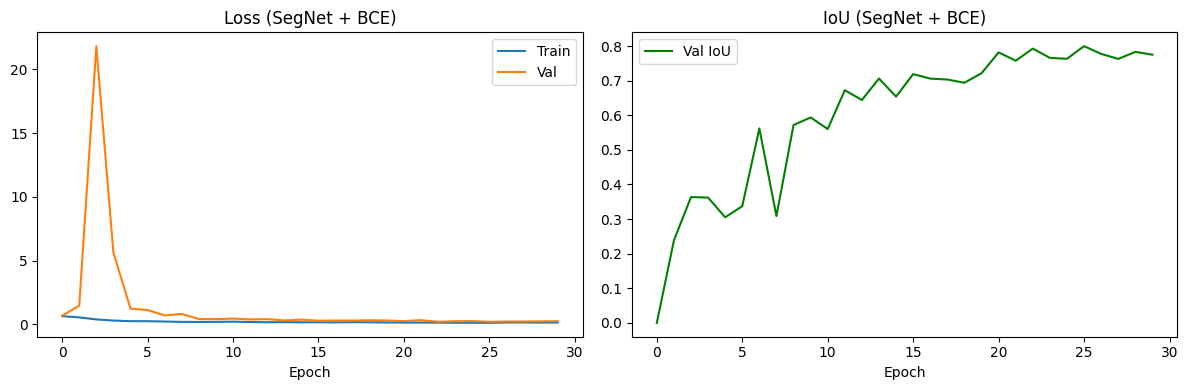

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_segnet_bce['train_loss'], label='Train')
plt.plot(history_segnet_bce['val_loss'],   label='Val')
plt.title('Loss (SegNet + BCE)')
plt.xlabel('Epoch'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_segnet_bce['val_iou'], label='Val IoU', color='green')
plt.title('IoU (SegNet + BCE)')
plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()


## Шаг 6. Инференс [1 балл]

После обучения модели напишите функцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [34]:
def test(model, test_loader, iou_fn, device):
    model.eval()
    total_iou = 0.0

    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            total_iou += iou_fn(torch.sigmoid(preds), masks.int()).item()

    mean_iou = total_iou / len(test_loader)
    print(f'Test IoU: {mean_iou:.4f}')

    return mean_iou


In [ ]:
test(segnet_model, test_dataloader, iou_score, device)

Test IoU: 0.7603


0.7602511942386627

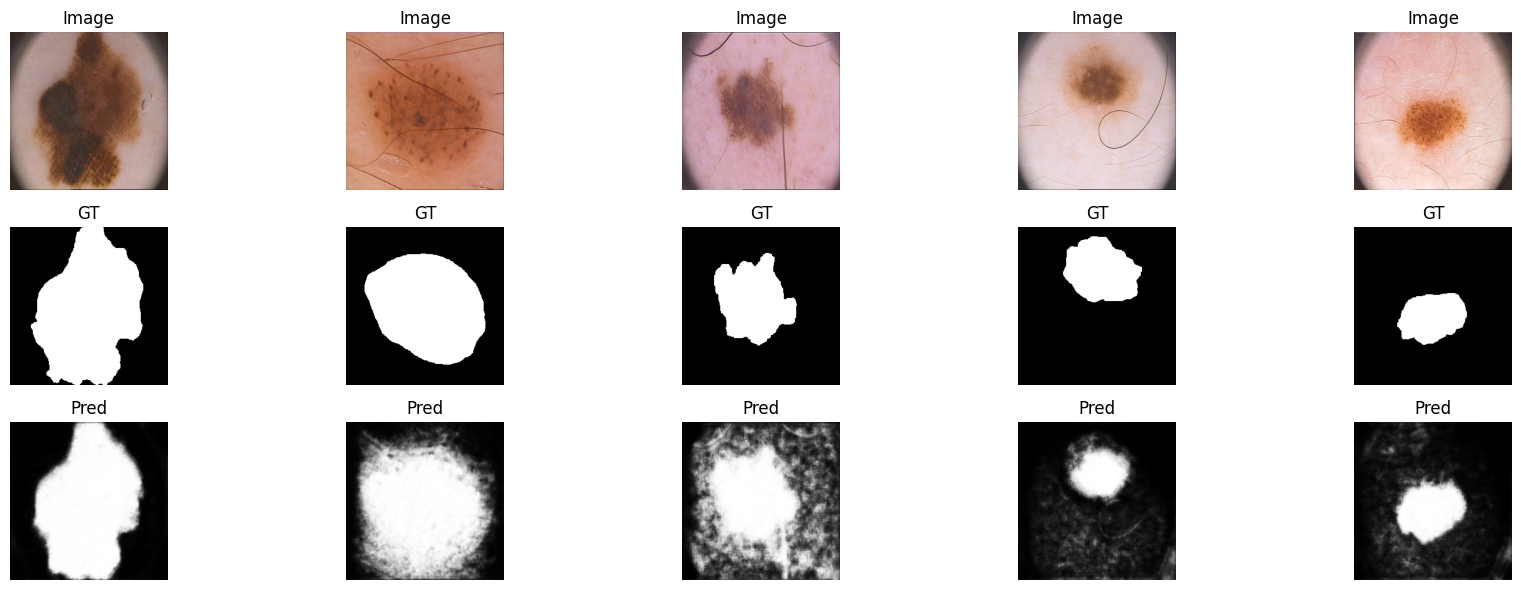

In [ ]:
segnet_model.eval()
images_batch, masks_batch = next(iter(test_dataloader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds_batch = torch.sigmoid(segnet_model(images_batch)).cpu()

plt.figure(figsize=(18, 6))
for i in range(5):
    img = images_batch[i].cpu().permute(1, 2, 0).numpy()
    plt.subplot(3, 5, i+1); plt.axis('off'); plt.title('Image'); plt.imshow(img)
    plt.subplot(3, 5, i+6); plt.axis('off'); plt.title('GT'); plt.imshow(masks_batch[i,0], cmap='gray')
    plt.subplot(3, 5, i+11); plt.axis('off'); plt.title('Pred'); plt.imshow(preds_batch[i,0], cmap='gray')
plt.tight_layout(); plt.show()

# Задания: Мир других лоссов!

## Пробуем другие функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.


### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [35]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    probs  = torch.sigmoid(logits)
    preds  = (probs >= threshold).float()
    labels = labels.float()

    tp = (preds * labels).sum()
    fp = (preds * (1 - labels)).sum()
    fn = ((1 - preds) * labels).sum()

    eps = 1e-8
    return (2 * tp + eps) / (2 * tp + fp + fn + eps)

Проверим на корректность функцию dice_score:

In [40]:
from torchmetrics.classification import BinaryF1Score

dice = BinaryF1Score(multidim_average='global').to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.6667)

In [ ]:
'''
если вы используете версию библиотеки 0.11.4, то можно взять torchmetrics.classification.Dice():

from torchmetrics.classification import Dice

dice = Dice(average='micro').to(device)

'''

In [41]:
assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

In [43]:
val_torchmetrics = dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))
val_ours = dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

print(f"torchmetrics: {val_torchmetrics.item()}")
print(f"наша: {val_ours.item()}")
print(f"разница: {abs(val_torchmetrics - val_ours).item():.2e}")

torchmetrics: 0.6666666865348816
наша: 0.6666666865348816
разница: 0.00e+00


Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [ ]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):
    probs  = torch.sigmoid(logits)
    labels = labels.float()

    tp = (probs * labels).sum()
    fp = (probs * (1 - labels)).sum()
    fn = ((1 - probs) * labels).sum()

    eps = 1e-8
    score = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    return 1 - score

Проверка на корректность:

In [ ]:
# проверьте, что у вас установлена библиотека
# !pip install segmentation-models-pytorch

In [ ]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [ ]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [ ]:
def focal_loss(y_real, y_pred, eps: float = 1e-8, gamma: float = 2.0):
    y_real = y_real.float()
    p = torch.sigmoid(y_pred)
    p_t = p * y_real + (1 - p) * (1 - y_real)
    bce = -(y_real * torch.log(p + eps) + (1 - y_real) * torch.log(1 - p + eps))
    return ((1 - p_t) ** gamma * bce).sum()


Проверка корректности функции:

In [ ]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [ ]:
assert sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum') == focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

## [BONUS] Мир сегментационных лоссов [5 баллов]

В данном блоке предлагаем вам написать одну функцию потерь самостоятельно. Для этого необходимо прочитать статью и имплементировать ее, и провести численное сравнение с предыдущими функциями.
 **ВАЖНО:** за имплементацию одного лосса выдается только один балл. Чтобы получить все 5 баллов, будет необходимо имплементировать все 5 лоссов.

* [Physiological Inspired Deep Neural Networks for Emotion Recognition](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=8472816&tag=1)". IEEE Access, 6, 53930-53943.

* [Boundary loss for highly unbalanced segmentation](https://arxiv.org/abs/1812.07032)

* [Tversky loss function for image segmentation using 3D fully convolutional deep networks](https://arxiv.org/abs/1706.05721)

* [Correlation Maximized Structural Similarity Loss for Semantic Segmentation](https://arxiv.org/abs/1910.08711)

* [Topology-Preserving Deep Image Segmentation](https://papers.nips.cc/paper/8803-topology-preserving-deep-image-segmentation)

### 1. Log-Cosh Dice Loss


In [ ]:
def log_cosh_dice_loss(logits: torch.Tensor, labels: torch.Tensor,
                       eps: float = 1e-8) -> torch.Tensor:

    probs  = torch.sigmoid(logits)
    labels = labels.float()

    tp = (probs * labels).sum()
    fp = (probs * (1 - labels)).sum()
    fn = ((1 - probs) * labels).sum()

    dice_coeff = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    dice_loss_val = 1.0 - dice_coeff

    return dice_loss_val + torch.log(1.0 + torch.exp(-2.0 * dice_loss_val)) - torch.log(torch.tensor(2.0))


In [ ]:
y_pred_test = torch.randn(2, 1, 4, 4)
y_true_test = torch.randint(0, 2, (2, 1, 4, 4))

lc_val = log_cosh_dice_loss(y_pred_test, y_true_test)
d_val  = dice_loss(y_pred_test, y_true_test)

print(f"Dice Loss = {d_val.item():.6f}")
print(f"Log-Cosh Dice Loss = {lc_val.item():.6f}")

print(f"log(cosh(dice)) = {torch.log(torch.cosh(d_val)).item():.6f} == {lc_val.item():.6f} "
      f"{'OK' if abs(torch.log(torch.cosh(d_val)).item() - lc_val.item()) < 1e-5 else 'FAIL'}")

Dice Loss = 0.487030
Log-Cosh Dice Loss = 0.114187
log(cosh(dice)) = 0.114187 == 0.114187 OK


### 2. Boundary Loss


In [ ]:
from scipy.ndimage import distance_transform_edt

In [ ]:
def _signed_distance_map(mask_np: np.ndarray) -> np.ndarray:
    mask_np = mask_np.astype(np.float32)
    if mask_np.max() == 0:
        return np.zeros_like(mask_np)
    if mask_np.min() == 1:
        return np.ones_like(mask_np)

    dist_in = distance_transform_edt(mask_np)
    dist_out = distance_transform_edt(1.0 - mask_np)
    sdm = dist_in - dist_out
    norm = np.abs(sdm).max()
    return sdm / (norm + 1e-8)


def boundary_loss(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    labels_np = labels.detach().cpu().numpy().astype(np.float32)

    B = labels_np.shape[0]
    sdm_list = []
    for b in range(B):
        sdm_list.append(_signed_distance_map(labels_np[b, 0]))

    sdm_batch = np.stack(sdm_list, axis=0)[:, np.newaxis, :, :]  # (B,1,H,W)
    sdm_tensor = torch.tensor(sdm_batch, dtype=torch.float32, device=logits.device)

    return (probs * sdm_tensor).mean()

In [ ]:
bl_val = boundary_loss(y_pred_test, y_true_test)
print(f"Boundary Loss = {bl_val.item():.6f}")


Boundary Loss = -0.001398


### 3. Tversky Loss


In [ ]:
def tversky_loss(logits: torch.Tensor, labels: torch.Tensor,
                 alpha: float = 0.5, beta: float = 0.5,
                 eps: float = 1e-8) -> torch.Tensor:
    """
    при alpha = beta = 0.5 совпадает с dice loss
    """
    probs  = torch.sigmoid(logits)
    labels = labels.float()

    tp = (probs * labels).sum()
    fp = (probs * (1 - labels)).sum()
    fn = ((1 - probs) * labels).sum()

    tversky_index = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
    return 1.0 - tversky_index

In [ ]:
tversky_val = tversky_loss(y_pred_test, y_true_test)
dice_val_tver  = dice_loss(y_pred_test, y_true_test)
print(f"Dice Loss = {dice_val_tver.item():.6f}")
print(f"Tversky Loss (alpha=0.5, beta=0.5) = {tversky_val.item():.6f}")
assert np.isclose(dice_val_tver.item(), tversky_val.item(), atol=1e-5)

Dice Loss = 0.487030
Tversky Loss (alpha=0.5, beta=0.5) = 0.487030


### 4. SSIM Loss (Structural Similarity)


In [ ]:
def _gaussian_kernel_2d(size: int, sigma: float = 1.5,
                        device=None) -> torch.Tensor:

    coords = torch.arange(size, dtype=torch.float32, device=device) - size // 2
    g = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    kernel = g.unsqueeze(0) * g.unsqueeze(1)
    kernel = kernel / kernel.sum()
    return kernel.unsqueeze(0).unsqueeze(0)


def ssim_loss(logits: torch.Tensor, labels: torch.Tensor,
              window_size: int = 11, sigma: float = 1.5,
              eps: float = 1e-8) -> torch.Tensor:

    probs  = torch.sigmoid(logits)
    labels = labels.float()

    C1 = (0.01) ** 2
    C2 = (0.03) ** 2

    kernel = _gaussian_kernel_2d(window_size, sigma, device=logits.device)
    pad    = window_size // 2

    mu_p = F.conv2d(probs, kernel, padding=pad)
    mu_g = F.conv2d(labels, kernel, padding=pad)

    mu_p2 = mu_p ** 2
    mu_g2 = mu_g ** 2
    mu_pg = mu_p * mu_g

    sigma_p2 = F.conv2d(probs  ** 2, kernel, padding=pad) - mu_p2
    sigma_g2 = F.conv2d(labels ** 2, kernel, padding=pad) - mu_g2
    sigma_pg = F.conv2d(probs * labels, kernel, padding=pad) - mu_pg

    num  = (2 * mu_pg + C1) * (2 * sigma_pg + C2)
    den  = (mu_p2 + mu_g2 + C1) * (sigma_p2 + sigma_g2 + C2)
    ssim_map = num / (den + eps)

    return 1.0 - ssim_map.mean()

In [ ]:
ssim_val = ssim_loss(y_pred_test, y_true_test)
print(f"SSIM Loss = {ssim_val.item():.6f}")

SSIM Loss = 0.563744


### 5. Topology-Preserving Loss


In [ ]:
def topology_loss(logits: torch.Tensor, labels: torch.Tensor,
                  morph_size: int = 4, scale: int = 2,
                  lam1: float = 1.0, lam2: float = 0.5, lam3: float = 1.0,
                  eps: float = 1e-6) -> torch.Tensor:
    probs  = torch.sigmoid(logits)
    labels = labels.float()
    pad    = morph_size // 2

    p_dil = F.max_pool2d(probs,  kernel_size=morph_size, stride=1, padding=pad)
    g_dil = F.max_pool2d(labels, kernel_size=morph_size, stride=1, padding=pad)

    p_ero = -F.max_pool2d(-probs,  kernel_size=morph_size, stride=1, padding=pad)
    g_ero = -F.max_pool2d(-labels, kernel_size=morph_size, stride=1, padding=pad)

    p_topo = p_dil - p_ero
    g_topo = g_dil - g_ero

    loss_boundary = lam1 * F.mse_loss(p_topo, g_topo)

    p_down = F.avg_pool2d(probs,  kernel_size=scale, stride=scale)
    g_down = F.avg_pool2d(labels, kernel_size=scale, stride=scale)
    p_betti = p_down.mean(dim=[2, 3])   # (B, 1)
    g_betti = g_down.mean(dim=[2, 3])   # (B, 1)
    loss_betti = lam2 * F.mse_loss(p_betti, g_betti)

    g_topo_bin = (g_topo > 0.1).float().detach()
    p_topo_clamped = p_topo.clamp(eps, 1.0 - eps)
    loss_bce_topo = lam3 * F.binary_cross_entropy(p_topo_clamped, g_topo_bin)

    return loss_boundary + loss_betti + loss_bce_topo

In [ ]:
topo_val = topology_loss(y_pred_test, y_true_test)
print(f"Topology Loss = {topo_val.item():.6f}")

Topology Loss = 0.768079


In [ ]:
y_pred_cmp = dummpy_sample['logits'].cpu()
y_true_cmp = dummpy_sample['labels'].cpu()

results = {
    'BCE (baseline)': nn.BCEWithLogitsLoss(reduction='mean')(y_pred_cmp, y_true_cmp.float()).item(),
    'Dice (baseline)': dice_loss(y_pred_cmp, y_true_cmp).item(),
    'Focal γ=2 (baseline)': focal_loss(y_true_cmp, y_pred_cmp, gamma=2.0).item(),
    'Log-Cosh Dice': log_cosh_dice_loss(y_pred_cmp, y_true_cmp).item(),
    'Boundary Loss': boundary_loss(y_pred_cmp, y_true_cmp).item(),
    'Tversky α=0.5': tversky_loss(y_pred_cmp, y_true_cmp, alpha=0.3, beta=0.7).item(),
    'SSIM Loss': ssim_loss(y_pred_cmp, y_true_cmp).item(),
    'Topology Loss': topology_loss(y_pred_cmp, y_true_cmp).item(),
}

print(f"{'Функция потерь':<35} {'Значение':>10}")
for name, val in results.items():
    print(f"  {name:<33} {val:>10.6f}")

Функция потерь                        Значение
  BCE (baseline)                      0.373395
  Dice (baseline)                     0.575600
  Focal γ=2 (baseline)                3.616124
  Log-Cosh Dice                       0.157245
  Boundary Loss                      -0.005188
  Tversky α=0.5                       0.598642
  SSIM Loss                           0.522085
  Topology Loss                       0.971634


/tmp/ipykernel_1249/627425106.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=35, ha='right', fontsize=9)


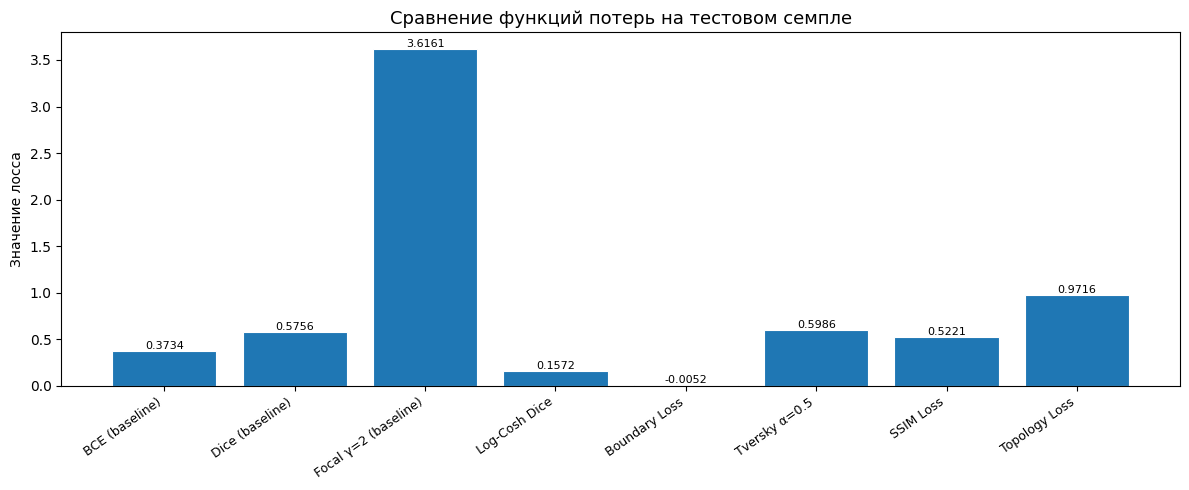

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
names = list(results.keys())
vals = [abs(v) for v in results.values()]

bars = ax.bar(names, vals, edgecolor='white', linewidth=0.8)
ax.set_title('Сравнение функций потерь на тестовом семпле', fontsize=13)
ax.set_ylabel('Значение лосса')
ax.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
for bar, val in zip(bars, list(results.values())):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
import functools

def tversky_loss_wrapper(y_pred, y_real):
    return tversky_loss(y_pred, y_real, alpha=0.42, beta=0.58)

def log_cosh_dice_wrapper(y_pred, y_real):
    return log_cosh_dice_loss(y_pred, y_real)

def boundary_loss_wrapper(y_pred, y_real):
    return boundary_loss(y_pred, y_real)

def ssim_loss_wrapper(y_pred, y_real):
    return ssim_loss(y_pred, y_real)

def topology_loss_wrapper(y_pred, y_real):
    return topology_loss(y_pred, y_real)

bonus_losses = {
    'LogCoshDice': log_cosh_dice_wrapper,
    'Boundary': boundary_loss_wrapper,
    'Tversky': tversky_loss_wrapper,
    'SSIM': ssim_loss_wrapper,
    'Topology': topology_loss_wrapper,
}

bonus_histories = {}
for loss_name, loss_fn in bonus_losses.items():
    print(f"  Обучение SegNet + {loss_name}")
    model = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
    history = train(
        model=model,
        train_loader=train_dataloader,
        valid_loader=valid_dataloader,
        loss_fn=loss_fn,
        iou_fn=iou_score,
        device=device,
        n_epochs=30,
        lr=1e-3,
    )
    bonus_histories[loss_name] = history
    test_iou = test(model, test_dataloader, iou_score, device)
    print(f"Test IoU (SegNet + {loss_name}): {test_iou:.4f}")


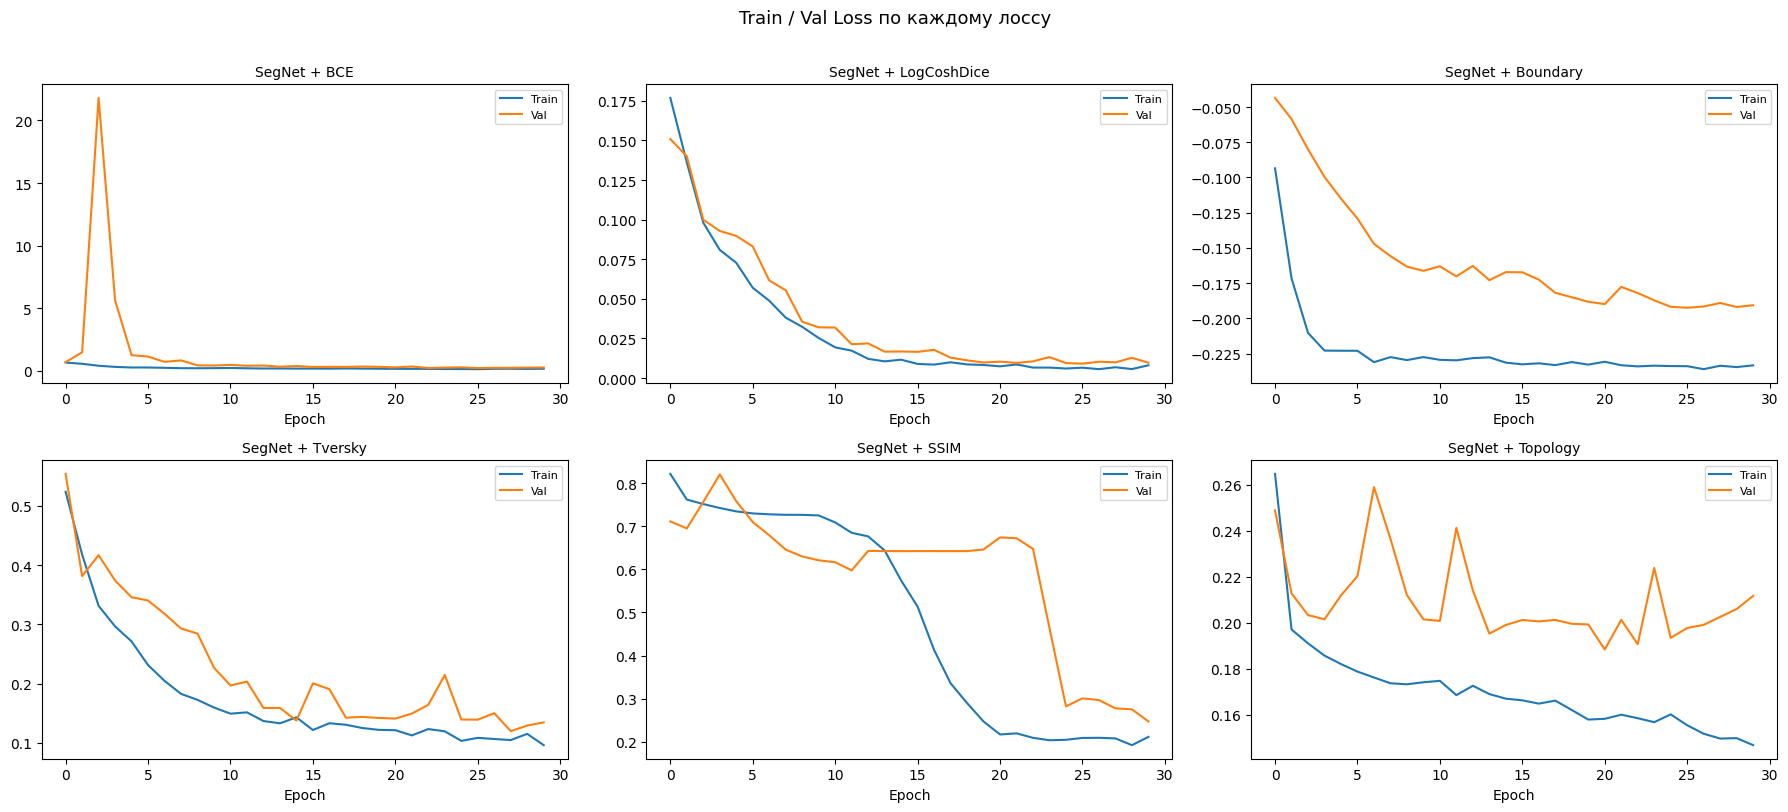

In [ ]:
all_names     = ['BCE'] + list(bonus_histories.keys())
all_histories = [history_segnet_bce] + list(bonus_histories.values())

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, name, hist in zip(axes.flat, all_names, all_histories):
    ax.plot(hist['train_loss'], label='Train')
    ax.plot(hist['val_loss'],   label='Val')
    ax.set_title(f'SegNet + {name}', fontsize=10)
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
plt.suptitle('Train / Val Loss по каждому лоссу', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [ ]:
segnet_dice = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
history_segnet_dice = train(
    segnet_dice, train_dataloader, valid_dataloader,
    loss_fn=dice_loss, iou_fn=iou_score, device=device, n_epochs=30, lr=1e-3
)

test(segnet_dice, test_dataloader, iou_score, device)


In [ ]:
import functools

focal_loss_fn = functools.partial(focal_loss, gamma=2.0)

def focal_loss_wrapper(y_pred, y_real):
    return focal_loss(y_real, y_pred, gamma=2.0)

segnet_focal = SegNet(in_channels=3, out_channels=1, num_features=64).to(device)
history_segnet_focal = train(
    segnet_focal, train_dataloader, valid_dataloader,
    loss_fn=focal_loss_wrapper, iou_fn=iou_score, device=device, n_epochs=30, lr=1e-3
)

test(segnet_focal, test_dataloader, iou_score, device)

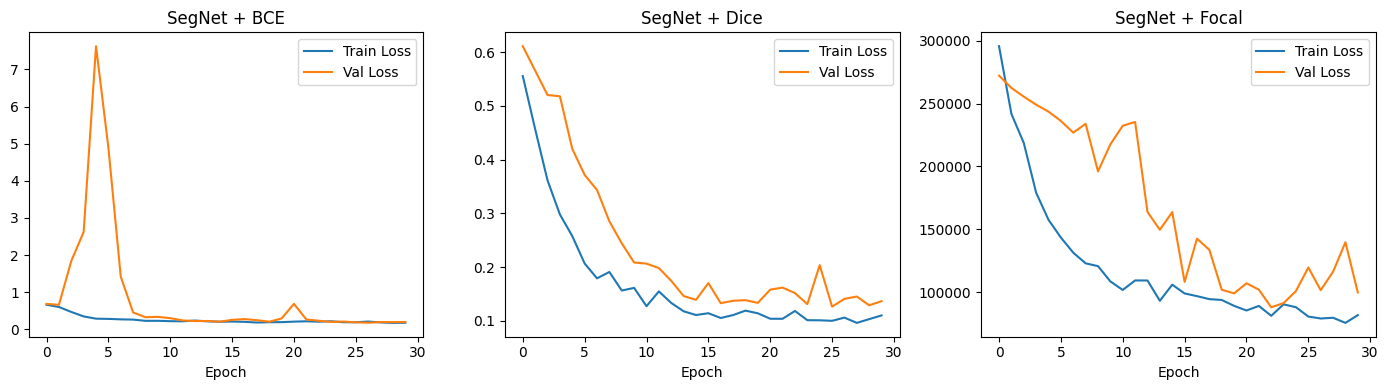

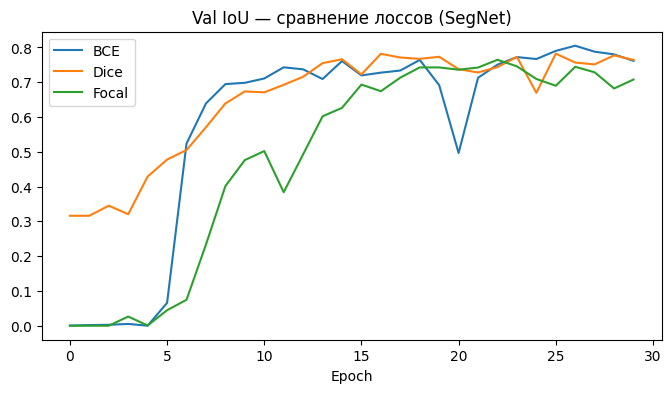

In [ ]:
labels = ['BCE', 'Dice', 'Focal']
histories = [history_segnet_bce, history_segnet_dice, history_segnet_focal]

plt.figure(figsize=(14, 4))
for i, (h, lbl) in enumerate(zip(histories, labels)):
    plt.subplot(1, 3, i+1)
    plt.plot(h['train_loss'], label='Train Loss')
    plt.plot(h['val_loss'],   label='Val Loss')
    plt.title(f'SegNet + {lbl}'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 4))
for h, lbl in zip(histories, labels):
    plt.plot(h['val_iou'], label=lbl)
plt.title('Val IoU — сравнение лоссов (SegNet)')
plt.xlabel('Epoch'); plt.legend(); plt.show()


1. Как видно из графиков, при BCE сходимость намного быстрее, чем при Dice и Focal. Dice в свою очередь сходится медленнее в начале, но потенциально она более устойчива к дисбалансу классов. А Focal требует правильного подбора гиперпараметра, потенциально можно подобрать такой параметр $\gamma$ что сходимость будет близка к BCE.

2. Видно что BCE и Dice близки друг к другу и их разность уменьшается при увеличении кол-ва эпох. Но за счет быстрой сходимости BSE предпочтительнее.

# Задание: Новая модель!

## Модель U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

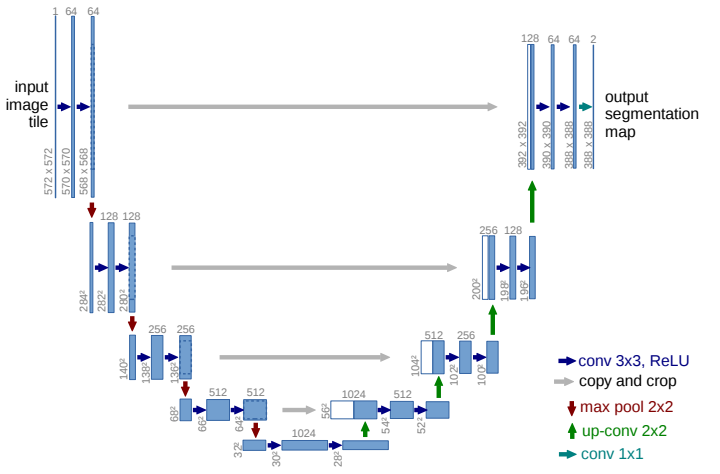

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

В оригинальной статье авторы не использовали padding внутри модели (это видно по тому, что размеры карты признаков уменьшаются на 2 каждый раз при движении от слоя к слою). При этом размеры входных изображений авторы единоразово увеличили при помощи mirror padding.

В этом домашнем задании вы можете применить альтернативный подход - сохранять размеры карт признаков при помощью padding = 1 во внутренних слоях.  

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

Для реализации UNet вы можете написать классы блоков энкодера и декодера отдельно, как мы сделали при реализации SegNet.

In [ ]:
class UNetConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_class=1, in_channels=3, base_features=64):
        super().__init__()
        f = base_features

        # Encoder
        self.enc1 = UNetConvBlock(in_channels, f)
        self.enc2 = UNetConvBlock(f, f * 2)
        self.enc3 = UNetConvBlock(f * 2, f * 4)
        self.enc4 = UNetConvBlock(f * 4, f * 8)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = UNetConvBlock(f * 8, f * 16)

        # Decoder
        self.up4  = nn.ConvTranspose2d(f * 16, f * 8, 2, stride=2)
        self.dec4 = UNetConvBlock(f * 16, f * 8)
        self.up3  = nn.ConvTranspose2d(f * 8, f * 4, 2, stride=2)
        self.dec3 = UNetConvBlock(f * 8, f * 4)
        self.up2  = nn.ConvTranspose2d(f * 4, f * 2, 2, stride=2)
        self.dec2 = UNetConvBlock(f * 4, f * 2)
        self.up1  = nn.ConvTranspose2d(f * 2, f, 2, stride=2)
        self.dec1 = UNetConvBlock(f * 2, f)
        self.final_conv = nn.Conv2d(f, n_class, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b  = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final_conv(d1)

In [ ]:
unet_bce = UNet(n_class=1, in_channels=3).to(device)
history_unet_bce = train(
    unet_bce, train_dataloader, valid_dataloader,
    loss_fn=loss_fn_bce, iou_fn=iou_score, device=device, n_epochs=30, lr=1e-3
)

test(unet_bce, test_dataloader, iou_score, device)

In [ ]:
unet_dice = UNet(n_class=1, in_channels=3).to(device)
history_unet_dice = train(
    unet_dice, train_dataloader, valid_dataloader,
    loss_fn=dice_loss, iou_fn=iou_score, device=device, n_epochs=30, lr=1e-3
)

test(unet_dice, test_dataloader, iou_score, device)

In [ ]:
unet_focal = UNet(n_class=1, in_channels=3).to(device)
history_unet_focal = train(
    unet_focal, train_dataloader, valid_dataloader,
    loss_fn=focal_loss_wrapper, iou_fn=iou_score, device=device, n_epochs=30, lr=1e-3
)

test(unet_focal, test_dataloader, iou_score, device)

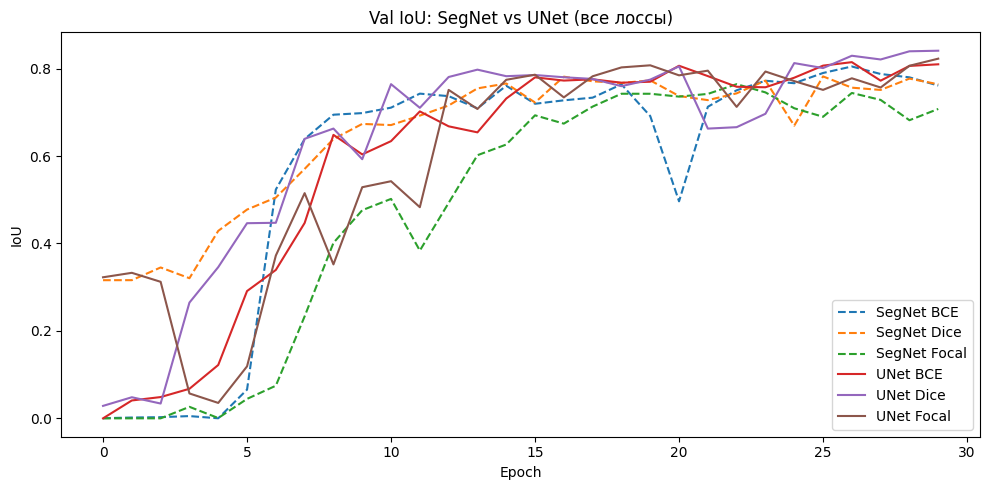

In [ ]:
all_histories = {
    'SegNet BCE': history_segnet_bce,
    'SegNet Dice': history_segnet_dice,
    'SegNet Focal': history_segnet_focal,
    'UNet BCE': history_unet_bce,
    'UNet Dice': history_unet_dice,
    'UNet Focal': history_unet_focal,
}

plt.figure(figsize=(10, 5))
for name, h in all_histories.items():
    style = '--' if 'SegNet' in name else '-'
    plt.plot(h['val_iou'], linestyle=style, label=name)
plt.title('Val IoU: SegNet vs UNet (все лоссы)')
plt.xlabel('Epoch'); plt.ylabel('IoU'); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()


In [ ]:
test(unet_bce, test_dataloader, iou_score, device)

Test IoU: 0.7915


0.7915485799312592

In [ ]:
test(unet_dice, test_dataloader, iou_score, device)


Test IoU: 0.8216


0.8215936124324799

In [ ]:
test(unet_focal, test_dataloader, iou_score, device)

Test IoU: 0.8012


0.8011904358863831

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



Выводы:
1. Модель UNet несколько превосходит SegNet за счет skip-connections (как описывалось в блоке теории)
2. UNet также дает лучшие значения по лоссам (Возможно надо поигратться с гаммой для Focal и повысить точность, я это понимаю):

Test IoU (UNet + BCE): 0.7915

Test IoU (UNet + Dice): 0.8216

Test IoU (UNet + Focal): 0.8012

3. SegNet обучается быстрее так как она имеет меньшее число параметров (В ней нет скип-конекшн и конв-транспор слоев)

4. Визуальное сравнение также показывает, что UNet модель лучше, она дает более точную сегментацию

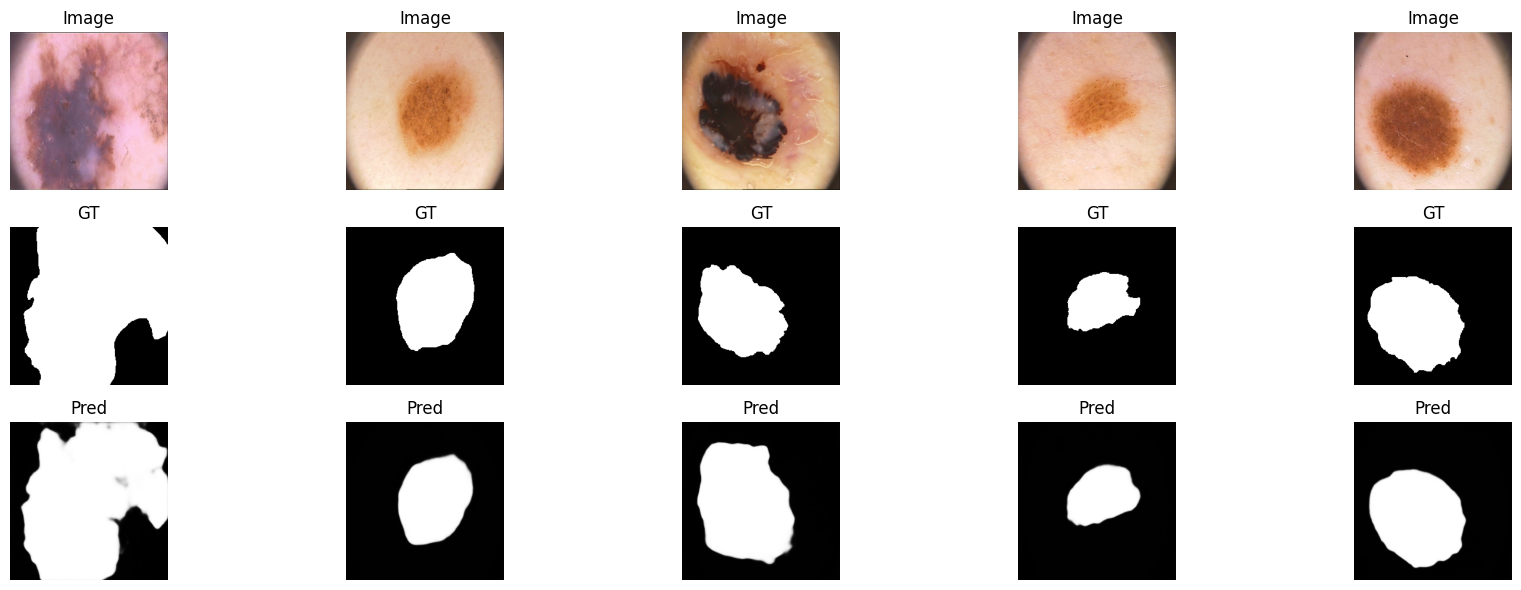

In [ ]:
unet_dice.eval()

images_batch, masks_batch = next(iter(valid_dataloader))
images_batch = images_batch.to(device)

with torch.no_grad():
    preds_batch = torch.sigmoid(unet_dice(images_batch)).cpu()

plt.figure(figsize=(18, 6))
for i in range(5):
    img = images_batch[i].cpu().permute(1, 2, 0).numpy()

    plt.subplot(3, 5, i + 1)
    plt.axis('off')
    plt.title('Image')
    plt.imshow(img)

    plt.subplot(3, 5, i + 6)
    plt.axis('off')
    plt.title('GT')
    plt.imshow(masks_batch[i, 0], cmap='gray')

    plt.subplot(3, 5, i + 11)
    plt.axis('off')
    plt.title('Pred')
    plt.imshow(preds_batch[i, 0], cmap='gray')

plt.tight_layout()
plt.show()